In [1]:
import open3d as o3d
import os
import glob
import numpy as np
import h5py
from matplotlib import pyplot as plt
from generate_hdf5_dataset_with_padding import generate_hdf5_dataset_with_padding
import random
import getpass
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# CHANGEABLES
NUM_SAMPLES = 1200
NUM_POINTS = 4096
DATASET_DIR = r"D:\Datasets\MinimarketPointCloud\MiniMarket_raw"
SAVE_DIR = r"D:\Datasets\MinimarketPointCloud\MiniMarket_hdf5"
my_product_name= "ketchup_heinz_400ml"
EAN_code = "8715700122144"

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.17.0


In [5]:
MY_PRODUCT_DIR = os.path.join(DATASET_DIR, my_product_name)
SAVE_DIR = os.path.join(SAVE_DIR, "generated_dataset")
my_product_dataset_name = my_product_name+ "_" + str(NUM_SAMPLES) + "_" + str(NUM_POINTS) + "_" + EAN_code + ".h5"
generate_hdf5_dataset_with_padding(MY_PRODUCT_DIR, my_product_dataset_name, NUM_POINTS);

hdf5_file_path = my_product_dataset_name  # e.g., 'coffee_kenco_100gm_1200_2048_8711000519325.h5'
# Open the file in read mode
with h5py.File(hdf5_file_path, 'r') as f:
    # Read datasets
    point_clouds = f["point_clouds"][:]  # shape: (1200, 2048, 3)
    color_clouds = f["color_clouds"][:]  # shape: (1200, 2048, 3)
print(point_clouds.shape)
print(color_clouds.shape)

path_:  D:\Datasets\MinimarketPointCloud\MiniMarket_raw\ketchup_heinz_400ml
files ['D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam1.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam2.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam3.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam4.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam5.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam6.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam7.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam8.pcd', 'D:\\Datasets\\MinimarketPointCloud\\

Random sample index: 59


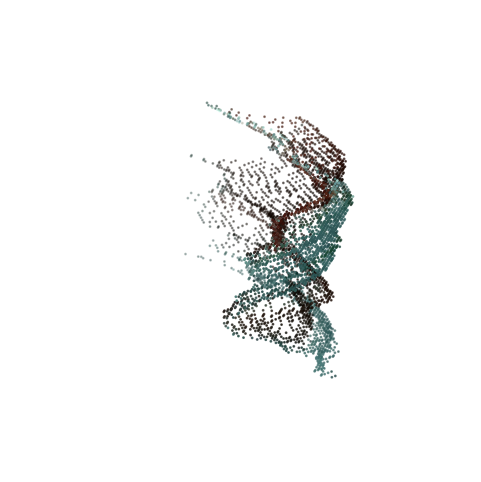

In [10]:
N = random.randint(0, NUM_SAMPLES-1)
print("Random sample index:", N)
points_sample = point_clouds[N, :, :]
colors_sample = color_clouds[N, :, :]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
           c=colors_sample, s=1)
ax.set_axis_off()
plt.show()


In [11]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_sample)
pcd.colors = o3d.utility.Vector3dVector(colors_sample)
o3d.visualization.draw_geometries([pcd])